In [1]:
# Cell 0 — Clone repo (Colab only)
import os, subprocess
if 'google.colab' in str(get_ipython()):
    REPO_DIR = '/content/trading-strategies'
    if not os.path.exists(os.path.join(REPO_DIR, 'lib', 'data_manager.py')):
        if os.path.exists(REPO_DIR):
            import shutil
            shutil.rmtree(REPO_DIR)
        result = subprocess.run(['git', 'clone', 'https://github.com/r-giov/trading-strategies.git', REPO_DIR], capture_output=True, text=True)
        if result.returncode != 0:
            try:
                from google.colab import userdata
                token = userdata.get('GITHUB_TOKEN')
            except Exception:
                token = None
            if not token:
                raise RuntimeError("Git clone failed. Add GITHUB_TOKEN as Colab secret.")
            subprocess.run(['git', 'clone', f'https://{token}@github.com/r-giov/trading-strategies.git', REPO_DIR], capture_output=True, text=True)
    assert os.path.isfile(os.path.join(REPO_DIR, 'lib', 'data_manager.py')), "Clone failed"
    os.chdir(REPO_DIR)
    print(f"Repo ready at {REPO_DIR}")
else:
    print("Not in Colab")

Not in Colab


In [2]:
# !pip install yfinance
# !pip install TA-Lib
# !pip install numpy
# !pip install pandas
# !pip install vectorbt
# !pip install scipy
# !pip install matplotlib

In [3]:
import sys, os

_repo = '/content/trading-strategies'
if os.path.isdir(os.path.join(_repo, 'lib')):
    if _repo not in sys.path:
        sys.path.insert(0, _repo)
else:
    _parent = os.path.join(os.getcwd(), '..')
    if os.path.isdir(os.path.join(_parent, 'lib')) and _parent not in sys.path:
        sys.path.insert(0, os.path.abspath(_parent))

import yfinance as yf
import talib
import numpy as np
import pandas as pd
import vectorbt as vbt
import warnings
from scipy import stats
import matplotlib.pyplot as plt
from itertools import product

warnings.filterwarnings('ignore')
pd.set_option('future.no_silent_downcasting', True)
pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 140)

print(f"\nPackages: vectorbt={vbt.__version__}, pandas={pd.__version__}, numpy={np.__version__}")
print("All imports loaded")


Packages: vectorbt=0.28.1, pandas=2.3.2, numpy=2.3.3
All imports loaded


In [4]:
# ═══════════════════════════════════════════════════════════════
# CONFIGURATION — Stochastic Mean Reversion
# ═══════════════════════════════════════════════════════════════

TICKERS = ['GC=F', 'SI=F', 'CL=F', 'HG=F', 'PL=F']
PRIMARY_TICKER = 'GC=F'
START_DATE = '2010-01-01'

print(f"Downloading daily data for {len(TICKERS)} tickers from {START_DATE}...\n")

all_data = {}
for ticker in TICKERS:
    df = yf.download(ticker, start=START_DATE, progress=False)
    if df is not None and not df.empty:
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = [c[0] for c in df.columns]
        df = df.dropna()
        all_data[ticker] = df
        print(f"  {ticker}: {len(df)} bars ({df.index[0].date()} to {df.index[-1].date()})")

stock_data = all_data[PRIMARY_TICKER]
TICKER = PRIMARY_TICKER
print(f"\nPrimary: {TICKER} — {len(stock_data)} daily bars")
stock_data.tail(5)

  GC=F: 4068 bars (2010-01-04 to 2026-03-08)


  SI=F: 4068 bars (2010-01-04 to 2026-03-08)


  CL=F: 4069 bars (2010-01-04 to 2026-03-08)


  HG=F: 4069 bars (2010-01-04 to 2026-03-08)


  PL=F: 4067 bars (2010-01-04 to 2026-03-08)

Primary: GC=F — 4068 daily bars


,Close,High,Low,Open,Volume
Date,,,,,
2026-03-03,5107.399902,5303.799805,5023.000000,5298.700195,1776
2026-03-04,5120.200195,5180.200195,5117.200195,5130.700195,679
2026-03-05,5065.299805,5169.500000,5054.700195,5169.500000,1701
2026-03-06,5146.100098,5146.100098,5076.100098,5121.000000,1701
2026-03-08,5105.600098,5210.399902,5094.500000,5186.700195,11721


In [5]:
# ═══════════════════════════════════════════════════════════════
# INDICATOR OVERVIEW — Stochastic + SMA + ATR
# ═══════════════════════════════════════════════════════════════

close = stock_data['Close'].values.astype(float)
high = stock_data['High'].values.astype(float)
low = stock_data['Low'].values.astype(float)
idx = stock_data.index

slowk, slowd = talib.STOCH(high, low, close, fastk_period=5, slowk_period=3, slowd_period=5)
indicators_df = pd.DataFrame({
    'Close': close,
    'Stoch_K': slowk,
    'Stoch_D': slowd,
    'SMA_50': talib.SMA(close, timeperiod=50),
    'SMA_100': talib.SMA(close, timeperiod=100),
    'SMA_200': talib.SMA(close, timeperiod=200),
    'ATR_14': talib.ATR(high, low, close, timeperiod=14),
    'ADX_14': talib.ADX(high, low, close, timeperiod=14),
}, index=idx)

print(f"Indicators computed for {TICKER}")
print(f"\nStochastic(5,3,5) stats:")
print(f"  Mean %K: {indicators_df['Stoch_K'].mean():.1f}")
print(f"  Days %K < 30 (oversold): {(indicators_df['Stoch_K'] < 30).sum()} ({(indicators_df['Stoch_K'] < 30).mean()*100:.1f}%)")
print(f"  Days %K > 70 (overbought): {(indicators_df['Stoch_K'] > 70).sum()} ({(indicators_df['Stoch_K'] > 70).mean()*100:.1f}%)")
print(f"\nATR(14) avg: ${indicators_df['ATR_14'].mean():.2f}")
indicators_df.tail(10)

Indicators computed for GC=F

Stochastic(5,3,5) stats:
  Mean %K: 53.3
  Days %K < 30 (oversold): 1021 (25.1%)
  Days %K > 70 (overbought): 1367 (33.6%)

ATR(14) avg: $21.45


,Close,Stoch_K,Stoch_D,SMA_50,SMA_100,SMA_200,ATR_14,ADX_14
Date,,,,,,,,
2026-02-24,5155.799805,91.944638,64.848249,4708.331992,4396.375986,3903.633990,151.809532,19.803708
2026-02-25,5206.399902,93.195335,75.138120,4726.749990,4409.764985,3912.988990,144.580287,19.573440
2026-02-26,5176.500000,87.029153,84.438521,4744.277988,4423.132986,3922.771490,138.717409,19.190191
2026-02-27,5230.500000,82.603653,87.472428,4762.753984,4436.629985,3932.722490,136.201880,19.288828
2026-03-02,5294.399902,70.726446,85.099845,4782.551982,4450.088984,3943.287490,138.937460,20.004385
2026-03-03,5107.399902,51.556239,77.022165,4797.749980,4461.396982,3952.720990,149.070484,18.938508
2026-03-04,5120.200195,36.567132,65.696525,4813.363984,4472.165984,3962.411991,143.622614,17.948764
2026-03-05,5065.299805,19.537513,52.198197,4827.441982,4483.355981,3971.593990,141.563842,16.700488
2026-03-06,5146.100098,22.914494,40.260365,4841.471982,4495.057983,3980.922991,137.223588,15.541373


In [6]:
# ═══════════════════════════════════════════════════════════════
# PREPARE PRICE SERIES — IS/OOS SPLIT (60/40)
# ═══════════════════════════════════════════════════════════════

TRAIN_RATIO = 0.60
INIT_CASH   = 100_000
FEES        = 0.0005
SLIPPAGE    = 0.0005

close_series = stock_data['Close'].astype(float)
close_series.name = 'price'
high_series = stock_data['High'].astype(float)
low_series = stock_data['Low'].astype(float)

split_idx = int(len(close_series) * TRAIN_RATIO)
train_close = close_series.iloc[:split_idx]
val_close   = close_series.iloc[split_idx:]

print(f"Total bars: {len(close_series)}")
print(f"Train/Val split at index {split_idx} ({TRAIN_RATIO:.0%}/{1-TRAIN_RATIO:.0%})")
print(f"  Train: {len(train_close)} bars | {train_close.index[0].date()} -> {train_close.index[-1].date()}")
print(f"  Val:   {len(val_close)} bars  | {val_close.index[0].date()} -> {val_close.index[-1].date()}")

Total bars: 4068
Train/Val split at index 2440 (60%/40%)
  Train: 2440 bars | 2010-01-04 -> 2019-09-17
  Val:   1628 bars  | 2019-09-18 -> 2026-03-08


## Stochastic Mean Reversion — Strategy Description

**Discovered by:** Strategy Discovery Engine (autonomous search across 10,000+ variants)

**Concept:** The Stochastic Oscillator measures momentum by comparing closing price to the price range over N periods. When %K drops below an oversold threshold and then crosses back above it, the asset is reverting from an oversold condition — a long entry signal. Combined with a trend filter (price > SMA), this ensures we only buy dips in an uptrend.

**Entry (Long only):**
- Stochastic %K crosses UP through the oversold threshold (e.g., 30)
- Price must be above the trend SMA (e.g., SMA 100) — only buy dips in uptrends

**Exit:**
- Stochastic %K crosses UP through the overbought threshold (e.g., 80)
- OR Stop Loss hit (ATR-based)
- OR Take Profit hit (ATR-based)

**Parameters to Optimize:**

| Parameter | Description | Range |
|---|---|---|
| `fastk_period` | Stochastic %K lookback | 5, 9, 14 |
| `slowk_period` | %K smoothing | 3, 5 |
| `slowd_period` | %D smoothing | 3, 5 |
| `oversold` | Entry threshold | 20, 25, 30, 35 |
| `overbought` | Exit threshold | 70, 75, 80, 85 |
| `trend_period` | SMA trend filter period | 50, 100, 200 |
| `sl_atr_mult` | Stop loss = ATR * mult | 1.0, 1.5, 2.0, 2.5 |
| `tp_atr_mult` | Take profit = ATR * mult | 2.0, 3.0, 4.0 |

**Discovery Engine Results (benchmark to beat):**
- GC=F OOS: Sharpe 1.445, Return +32.5%, MaxDD -7.0%, PF 4.46

In [7]:
# ═══════════════════════════════════════════════════════════════
# SIGNAL ENGINE — Stochastic Mean Reversion
# ═══════════════════════════════════════════════════════════════

def generate_stoch_mr_signals(close_s, high_s, low_s, fastk=5, slowk=3, slowd=5,
                               oversold=30, overbought=80, trend_period=100):
    """
    Stochastic Mean Reversion with trend filter.
    Entry: %K crosses up through oversold, price > SMA(trend_period)
    Exit: %K crosses up through overbought
    All signals shifted 1 bar for execution delay (anti-lookahead).
    """
    c = close_s.values.astype(float)
    h = high_s.values.astype(float)
    l = low_s.values.astype(float)
    idx = close_s.index

    slowk_vals, _ = talib.STOCH(h, l, c, fastk_period=fastk, slowk_period=slowk, slowd_period=slowd)
    stoch_k = pd.Series(slowk_vals, index=idx)
    trend = pd.Series(talib.SMA(c, timeperiod=trend_period), index=idx)
    price = pd.Series(c, index=idx)

    e_raw = (stoch_k.shift(1) <= oversold) & (stoch_k > oversold) & (price > trend)
    x_raw = (stoch_k.shift(1) <= overbought) & (stoch_k > overbought)

    entries = e_raw.shift(1).fillna(False).astype(bool)
    exits = x_raw.shift(1).fillna(False).astype(bool)
    return entries, exits


def compute_atr_stops(close_s, high_s, low_s, sl_mult=None, tp_mult=None, atr_period=14):
    """Compute ATR-based stop-loss and take-profit as fraction of price."""
    c = close_s.values.astype(float)
    h = high_s.values.astype(float)
    l = low_s.values.astype(float)
    atr = pd.Series(talib.ATR(h, l, c, timeperiod=atr_period), index=close_s.index)

    sl_stop = (atr * sl_mult / close_s).fillna(0.02) if sl_mult else None
    tp_stop = (atr * tp_mult / close_s).fillna(0.04) if tp_mult else None
    return sl_stop, tp_stop


# Parameter ranges
fastk_range    = [5, 9, 14]
slowk_range    = [3, 5]
slowd_range    = [3, 5]
oversold_range = [20, 25, 30, 35]
overbought_range = [70, 75, 80, 85]
trend_range    = [50, 100, 200]
sl_range       = [1.0, 1.5, 2.0, 2.5]
tp_range       = [2.0, 3.0, 4.0]

all_combos = list(product(fastk_range, slowk_range, slowd_range, oversold_range,
                           overbought_range, trend_range, sl_range, tp_range))
total_combos = len(all_combos)

print(f"Signal engine defined")
print(f"\nParameter Ranges:")
print(f"  fastk_period:  {fastk_range}")
print(f"  slowk_period:  {slowk_range}")
print(f"  slowd_period:  {slowd_range}")
print(f"  oversold:      {oversold_range}")
print(f"  overbought:    {overbought_range}")
print(f"  trend_period:  {trend_range}")
print(f"  sl_atr_mult:   {sl_range}")
print(f"  tp_atr_mult:   {tp_range}")
print(f"\nTotal combinations: {total_combos:,}")

# Sanity check
e_test, x_test = generate_stoch_mr_signals(close_series, high_series, low_series)
print(f"\nSanity check ({TICKER}, defaults): Entries={e_test.sum()}, Exits={x_test.sum()}")

Signal engine defined

Parameter Ranges:
  fastk_period:  [5, 9, 14]
  slowk_period:  [3, 5]
  slowd_period:  [3, 5]
  oversold:      [20, 25, 30, 35]
  overbought:    [70, 75, 80, 85]
  trend_period:  [50, 100, 200]
  sl_atr_mult:   [1.0, 1.5, 2.0, 2.5]
  tp_atr_mult:   [2.0, 3.0, 4.0]

Total combinations: 6,912

Sanity check (GC=F, defaults): Entries=135, Exits=266


In [8]:
# ═══════════════════════════════════════════════════════════════
# INITIALIZE RESULTS COLLECTION
# ═══════════════════════════════════════════════════════════════

grid_results = []

METRIC_COLS = [
    'fastk', 'slowk', 'slowd', 'oversold', 'overbought', 'trend_period', 'sl_atr_mult', 'tp_atr_mult',
    'sharpe_ratio', 'sortino_ratio', 'total_return', 'ann_return',
    'max_drawdown', 'volatility', 'calmar_ratio',
    'total_trades', 'trades_per_year', 'win_rate',
    'profit_factor', 'expectancy', 'avg_win', 'avg_loss',
    'largest_win', 'largest_loss', 'payoff_ratio',
]

print(f"Results collection initialized — tracking {len(METRIC_COLS)} metrics per combo")

Results collection initialized — tracking 25 metrics per combo


In [9]:
# ═══════════════════════════════════════════════════════════════
# GRID SEARCH — Training Data Only (IS)
# ═══════════════════════════════════════════════════════════════

print(f"Running grid search on {TICKER} training data ({total_combos:,} combos)...\n")

train_high = high_series.iloc[:split_idx]
train_low  = low_series.iloc[:split_idx]

for combo_idx, (fk, sk, sd, os_thr, ob_thr, tp, sl_m, tp_m) in enumerate(all_combos):
    if (combo_idx + 1) % 2000 == 0:
        print(f"  Combo {combo_idx+1:,}/{total_combos:,}... ({len(grid_results)} valid so far)")

    if os_thr >= ob_thr:
        continue

    try:
        ent, ext = generate_stoch_mr_signals(train_close, train_high, train_low,
                                              fastk=fk, slowk=sk, slowd=sd,
                                              oversold=os_thr, overbought=ob_thr,
                                              trend_period=tp)

        if ent.sum() < 5:
            continue

        sl_stop, tp_stop = compute_atr_stops(train_close, train_high, train_low,
                                              sl_mult=sl_m, tp_mult=tp_m)

        pf_kwargs = dict(init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, freq='D')
        if sl_stop is not None:
            pf_kwargs['sl_stop'] = sl_stop
        if tp_stop is not None:
            pf_kwargs['tp_stop'] = tp_stop

        pf = vbt.Portfolio.from_signals(close=train_close, entries=ent, exits=ext, **pf_kwargs)

        trades_obj = pf.trades
        n_trades = trades_obj.count()
        if n_trades < 5:
            continue

        tr = np.asarray(trades_obj.returns.values if hasattr(trades_obj.returns, 'values') else trades_obj.returns).ravel()
        pos = tr[tr > 0]
        neg = tr[tr < 0]
        years = max(len(train_close) / 252, 0.01)

        def safe(fn, default=np.nan):
            try: return float(fn())
            except: return default

        row = {
            'fastk': fk, 'slowk': sk, 'slowd': sd,
            'oversold': os_thr, 'overbought': ob_thr, 'trend_period': tp,
            'sl_atr_mult': sl_m, 'tp_atr_mult': tp_m,
            'sharpe_ratio': safe(lambda: pf.sharpe_ratio(freq='D')),
            'sortino_ratio': safe(lambda: pf.sortino_ratio(freq='D')),
            'total_return': safe(pf.total_return),
            'ann_return': safe(lambda: pf.annualized_return(freq='D')),
            'max_drawdown': safe(pf.max_drawdown),
            'volatility': safe(lambda: pf.annualized_volatility(freq='D')),
            'calmar_ratio': np.nan,
            'total_trades': int(n_trades),
            'trades_per_year': n_trades / years,
            'win_rate': float(len(pos) / len(tr) * 100) if len(tr) > 0 else np.nan,
            'profit_factor': float(pos.sum() / abs(neg.sum())) if len(neg) > 0 and abs(neg.sum()) > 0 else np.nan,
            'expectancy': float(tr.mean()) if len(tr) > 0 else np.nan,
            'avg_win': float(pos.mean()) if len(pos) > 0 else np.nan,
            'avg_loss': float(neg.mean()) if len(neg) > 0 else np.nan,
            'largest_win': float(pos.max()) if len(pos) > 0 else np.nan,
            'largest_loss': float(neg.min()) if len(neg) > 0 else np.nan,
            'payoff_ratio': float(abs(pos.mean() / neg.mean())) if len(pos) > 0 and len(neg) > 0 else np.nan,
        }

        ann_r = row['ann_return']
        max_dd = row['max_drawdown']
        if not np.isnan(ann_r) and not np.isnan(max_dd) and abs(max_dd) > 1e-9:
            row['calmar_ratio'] = ann_r / abs(max_dd)

        grid_results.append(row)
    except Exception:
        pass

results_df = pd.DataFrame(grid_results)
results_df = results_df.sort_values('sharpe_ratio', ascending=False).reset_index(drop=True)

print(f"\nGrid search complete: {len(results_df):,} valid combos out of {total_combos:,}")
print(f"\nTop 10 by Sharpe Ratio:")
print(f"{'Rank':<5} {'fk':>3} {'sk':>3} {'sd':>3} {'OS':>4} {'OB':>4} {'Trend':>6} {'SL':>5} {'TP':>5} {'Sharpe':>8} {'Return':>9} {'MaxDD':>8} {'Trades':>7} {'WR':>7} {'PF':>6}")
print("-" * 85)
for i, row in results_df.head(10).iterrows():
    print(f"{i+1:<5} {int(row['fastk']):>3} {int(row['slowk']):>3} {int(row['slowd']):>3} "
          f"{int(row['oversold']):>4} {int(row['overbought']):>4} {int(row['trend_period']):>6} "
          f"{row['sl_atr_mult']:>5.1f} {row['tp_atr_mult']:>5.1f} "
          f"{row['sharpe_ratio']:>8.3f} {row['total_return']:>9.2%} {row['max_drawdown']:>8.2%} "
          f"{int(row['total_trades']):>7} {row['win_rate']:>6.1f}% {row['profit_factor']:>6.2f}")

Running grid search on GC=F training data (6,912 combos)...



  Combo 2,000/6,912... (1999 valid so far)


  Combo 4,000/6,912... (3999 valid so far)


  Combo 6,000/6,912... (5999 valid so far)



Grid search complete: 6,912 valid combos out of 6,912

Top 10 by Sharpe Ratio:
Rank   fk  sk  sd   OS   OB  Trend    SL    TP   Sharpe    Return    MaxDD  Trades      WR     PF
-------------------------------------------------------------------------------------
1       9   3   5   35   70     50   2.5   3.0    0.648    22.72%   -5.54%      45   62.2%   2.10
2       9   3   3   35   70     50   2.5   3.0    0.648    22.72%   -5.54%      45   62.2%   2.10
3       9   3   3   35   70     50   2.5   4.0    0.645    22.59%   -5.54%      45   62.2%   2.09
4       9   3   5   35   70     50   2.5   4.0    0.645    22.59%   -5.54%      45   62.2%   2.09
5      14   3   3   30   70     50   2.5   2.0    0.633    18.36%   -6.67%      28   75.0%   2.40
6      14   3   5   30   70     50   2.5   2.0    0.633    18.36%   -6.67%      28   75.0%   2.40
7      14   3   5   30   70     50   2.5   3.0    0.617    17.96%   -6.67%      28   75.0%   2.38
8      14   3   3   30   70     50   2.5   3.0    

Validating top 5 IS combos on OOS data...

Rank  Params                                      IS SR   OOS SR    IS Ret   OOS Ret  IS Tr  OOS Tr
-----------------------------------------------------------------------------------------------
1     Stoch(9,3,5) OS=35 OB=70 T=50 SL=2.5 TP=3.0    0.648    0.332    22.72%     8.68%     45      38
2     Stoch(9,3,3) OS=35 OB=70 T=50 SL=2.5 TP=3.0    0.648    0.332    22.72%     8.68%     45      38
3     Stoch(9,3,3) OS=35 OB=70 T=50 SL=2.5 TP=4.0    0.645    0.332    22.59%     8.68%     45      38
4     Stoch(9,3,5) OS=35 OB=70 T=50 SL=2.5 TP=4.0    0.645    0.332    22.59%     8.68%     45      38
5     Stoch(14,3,3) OS=30 OB=70 T=50 SL=2.5 TP=2.0    0.633    0.215    18.36%     5.81%     28      27

Best OOS combo: Stoch(9,3,5) OS=35 OB=70 Trend=50 SL=2.5 TP=3.0


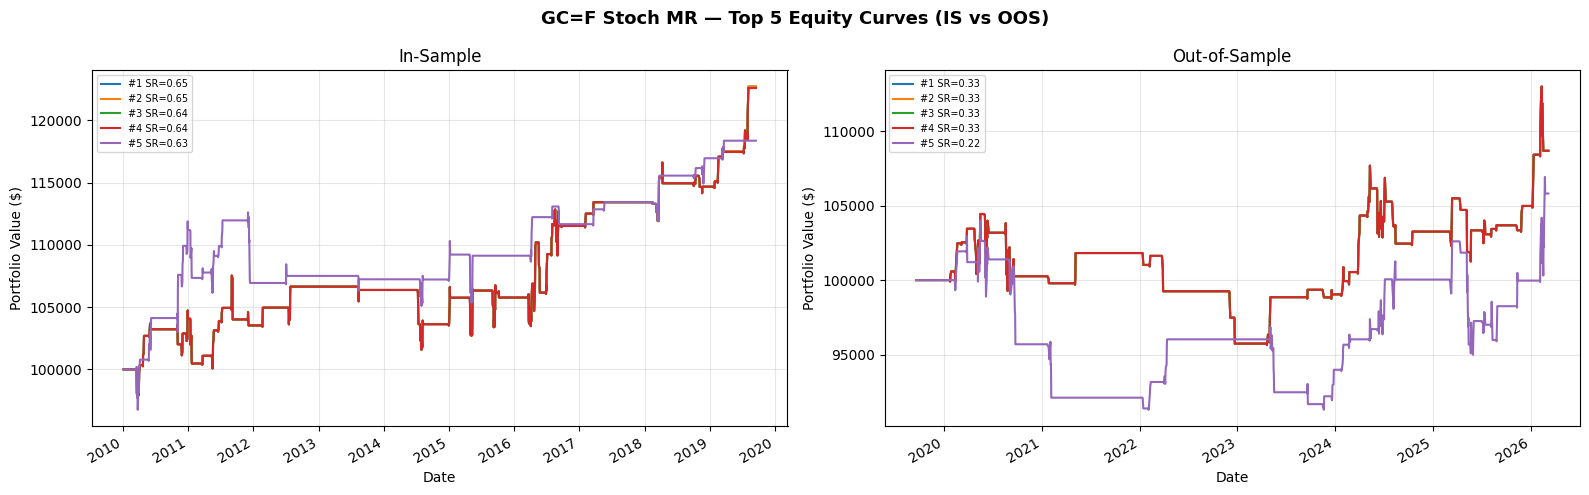

In [10]:
# ═══════════════════════════════════════════════════════════════
# TOP 5 OOS VALIDATION
# ═══════════════════════════════════════════════════════════════

top5 = results_df.head(5).copy()
val_high = high_series.iloc[split_idx:]
val_low  = low_series.iloc[split_idx:]

oos_results = []
is_portfolios = []
oos_portfolios = []

print(f"Validating top 5 IS combos on OOS data...\n")
print(f"{'Rank':<5} {'Params':<40} {'IS SR':>8} {'OOS SR':>8} {'IS Ret':>9} {'OOS Ret':>9} {'IS Tr':>6} {'OOS Tr':>7}")
print("-" * 95)

for rank, (_, row) in enumerate(top5.iterrows()):
    fk, sk, sd = int(row['fastk']), int(row['slowk']), int(row['slowd'])
    os_t, ob_t, tp = int(row['oversold']), int(row['overbought']), int(row['trend_period'])
    sl_m, tp_m = row['sl_atr_mult'], row['tp_atr_mult']
    param_str = f"Stoch({fk},{sk},{sd}) OS={os_t} OB={ob_t} T={tp} SL={sl_m} TP={tp_m}"

    # IS
    ent_is, ext_is = generate_stoch_mr_signals(train_close, train_high, train_low,
                                                fastk=fk, slowk=sk, slowd=sd,
                                                oversold=os_t, overbought=ob_t, trend_period=tp)
    sl_is, tp_is = compute_atr_stops(train_close, train_high, train_low, sl_mult=sl_m, tp_mult=tp_m)
    kw_is = dict(init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, freq='D')
    if sl_is is not None: kw_is['sl_stop'] = sl_is
    if tp_is is not None: kw_is['tp_stop'] = tp_is
    pf_is = vbt.Portfolio.from_signals(close=train_close, entries=ent_is, exits=ext_is, **kw_is)
    is_portfolios.append(pf_is)

    # OOS
    ent_oos, ext_oos = generate_stoch_mr_signals(val_close, val_high, val_low,
                                                  fastk=fk, slowk=sk, slowd=sd,
                                                  oversold=os_t, overbought=ob_t, trend_period=tp)
    sl_oos, tp_oos = compute_atr_stops(val_close, val_high, val_low, sl_mult=sl_m, tp_mult=tp_m)
    kw_oos = dict(init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, freq='D')
    if sl_oos is not None: kw_oos['sl_stop'] = sl_oos
    if tp_oos is not None: kw_oos['tp_stop'] = tp_oos
    pf_oos = vbt.Portfolio.from_signals(close=val_close, entries=ent_oos, exits=ext_oos, **kw_oos)
    oos_portfolios.append(pf_oos)

    def safe(fn, default=np.nan):
        try: return float(fn())
        except: return default

    is_sr = safe(lambda: pf_is.sharpe_ratio(freq='D'))
    oos_sr = safe(lambda: pf_oos.sharpe_ratio(freq='D'))
    is_ret = safe(pf_is.total_return)
    oos_ret = safe(pf_oos.total_return)
    is_trades = pf_is.trades.count()
    oos_trades = pf_oos.trades.count()

    oos_results.append({
        'rank': rank + 1, 'params': param_str,
        'fastk': fk, 'slowk': sk, 'slowd': sd,
        'oversold': os_t, 'overbought': ob_t, 'trend_period': tp,
        'sl_atr_mult': sl_m, 'tp_atr_mult': tp_m,
        'is_sharpe': is_sr, 'oos_sharpe': oos_sr,
        'is_return': is_ret, 'oos_return': oos_ret,
        'is_trades': is_trades, 'oos_trades': oos_trades,
    })

    print(f"{rank+1:<5} {param_str:<40} {is_sr:>8.3f} {oos_sr:>8.3f} {is_ret:>9.2%} {oos_ret:>9.2%} {is_trades:>6} {oos_trades:>7}")

oos_df = pd.DataFrame(oos_results)
best_idx = oos_df['oos_sharpe'].idxmax()
BEST = oos_df.loc[best_idx]
print(f"\nBest OOS combo: Stoch({int(BEST['fastk'])},{int(BEST['slowk'])},{int(BEST['slowd'])}) "
      f"OS={int(BEST['oversold'])} OB={int(BEST['overbought'])} Trend={int(BEST['trend_period'])} "
      f"SL={BEST['sl_atr_mult']} TP={BEST['tp_atr_mult']}")

# Plot equity curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'{TICKER} Stoch MR — Top 5 Equity Curves (IS vs OOS)', fontsize=13, fontweight='bold')
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i in range(len(is_portfolios)):
    r = oos_results[i]
    is_portfolios[i].value().plot(ax=axes[0], color=colors[i], linewidth=1.5,
                                   label=f"#{r['rank']} SR={r['is_sharpe']:.2f}")
    oos_portfolios[i].value().plot(ax=axes[1], color=colors[i], linewidth=1.5,
                                    label=f"#{r['rank']} SR={r['oos_sharpe']:.2f}")

for ax, title in zip(axes, ['In-Sample', 'Out-of-Sample']):
    ax.set_title(title); ax.set_ylabel('Portfolio Value ($)')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Sensitivity Analysis

How sensitive is the strategy's performance to each parameter? We sweep each parameter individually while holding others at the best values.

- Flat bars = **LOW** sensitivity (robust)
- Large swings = **HIGH** sensitivity (fragile)

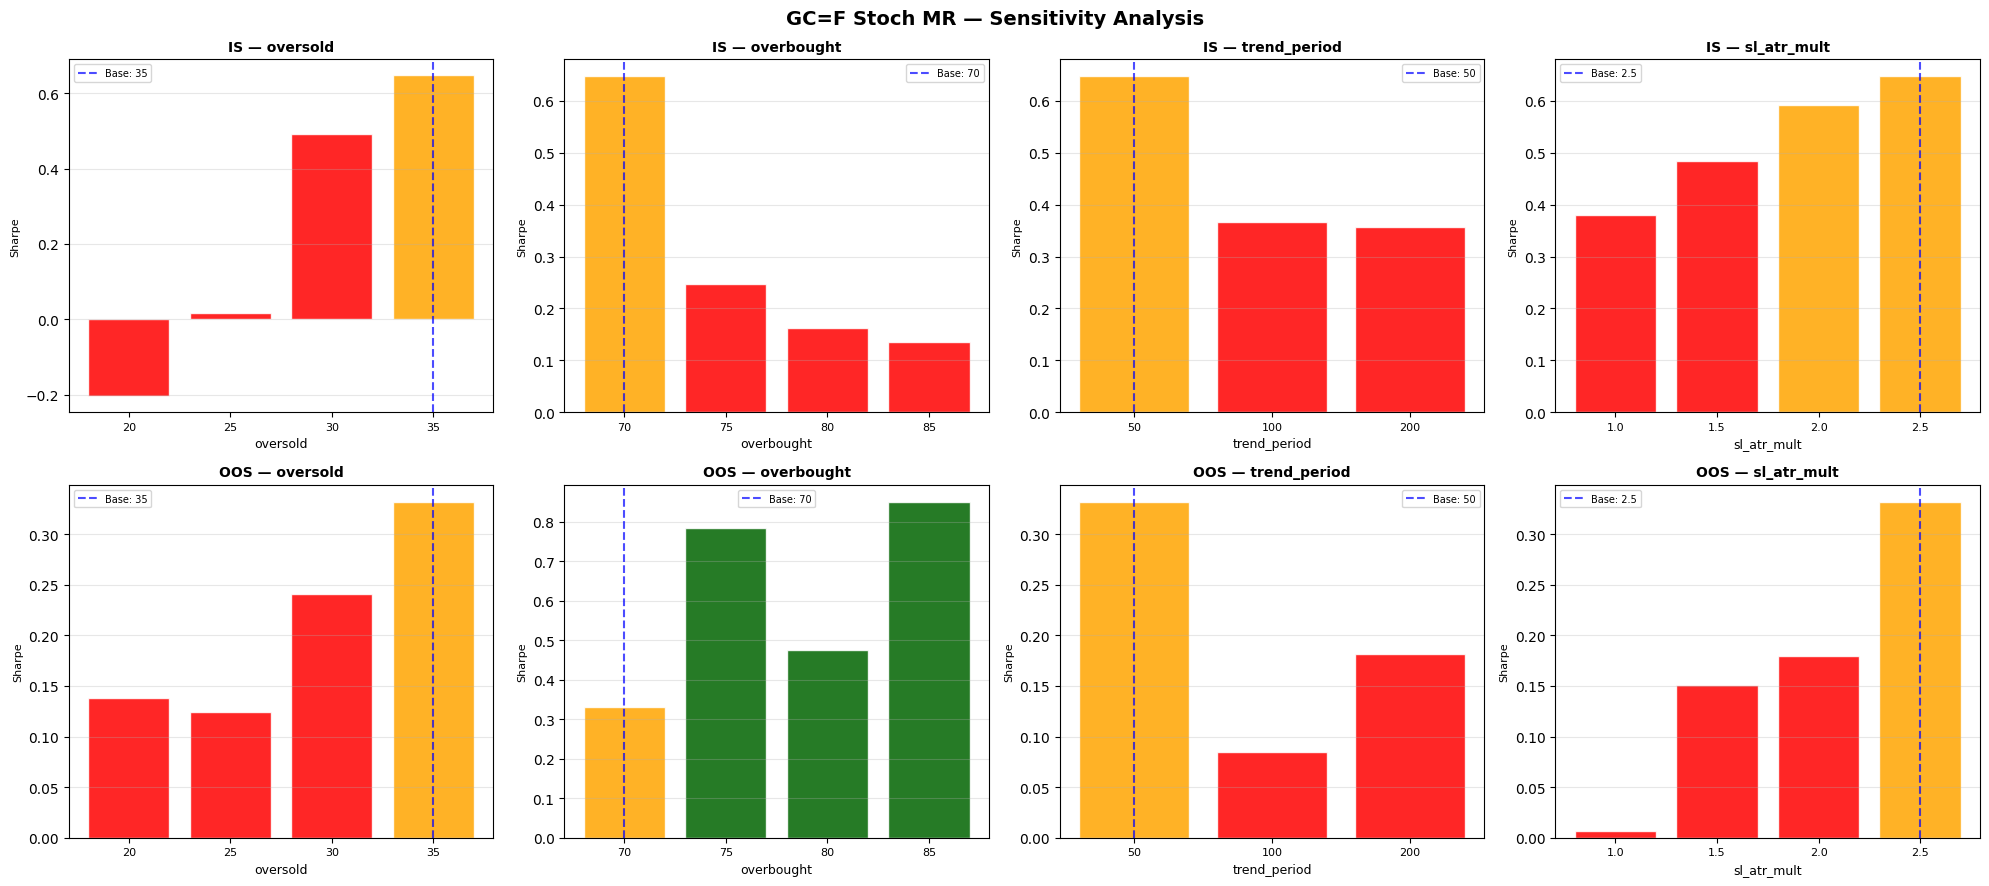


SENSITIVITY SUMMARY:
Parameter              IS Range  OOS Range  Sensitivity     Flag
-----------------------------------------------------------------
oversold                  0.852      0.207        2.374     HIGH
overbought                0.512      0.520        1.135     HIGH
trend_period              0.291      0.247        0.819     HIGH
sl_atr_mult               0.268      0.325        0.855     HIGH


In [11]:
# ═══════════════════════════════════════════════════════════════
# SENSITIVITY ANALYSIS
# ═══════════════════════════════════════════════════════════════

best_params = {
    'fastk': int(BEST['fastk']), 'slowk': int(BEST['slowk']), 'slowd': int(BEST['slowd']),
    'oversold': int(BEST['oversold']), 'overbought': int(BEST['overbought']),
    'trend_period': int(BEST['trend_period']),
    'sl_atr_mult': BEST['sl_atr_mult'], 'tp_atr_mult': BEST['tp_atr_mult'],
}

def run_sensitivity(close_s, high_s, low_s, param_name, param_values, base):
    sharpes = []
    for val in param_values:
        p = base.copy()
        p[param_name] = val
        try:
            sig_params = {k: p[k] for k in ['fastk', 'slowk', 'slowd', 'oversold', 'overbought', 'trend_period']}
            ent, ext = generate_stoch_mr_signals(close_s, high_s, low_s, **sig_params)
            sl, tp = compute_atr_stops(close_s, high_s, low_s, sl_mult=p['sl_atr_mult'], tp_mult=p['tp_atr_mult'])
            kw = dict(init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, freq='D')
            if sl is not None: kw['sl_stop'] = sl
            if tp is not None: kw['tp_stop'] = tp
            pf = vbt.Portfolio.from_signals(close=close_s, entries=ent, exits=ext, **kw)
            sr = float(pf.sharpe_ratio(freq='D'))
            sharpes.append(sr if not np.isnan(sr) else 0.0)
        except:
            sharpes.append(0.0)
    return sharpes

param_configs = [
    ('oversold', oversold_range, int(BEST['oversold'])),
    ('overbought', overbought_range, int(BEST['overbought'])),
    ('trend_period', trend_range, int(BEST['trend_period'])),
    ('sl_atr_mult', sl_range, BEST['sl_atr_mult']),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle(f'{TICKER} Stoch MR — Sensitivity Analysis', fontsize=14, fontweight='bold')
sensitivity_summary = []

for col, (pname, pvals, base_val) in enumerate(param_configs):
    is_sharpes = run_sensitivity(train_close, train_high, train_low, pname, pvals, best_params)
    oos_sharpes = run_sensitivity(val_close, val_high, val_low, pname, pvals, best_params)

    base_is = is_sharpes[pvals.index(base_val)] if base_val in pvals else np.mean(is_sharpes)
    base_oos = oos_sharpes[pvals.index(base_val)] if base_val in pvals else np.mean(oos_sharpes)

    for row_idx, (sharpes, prefix, base_sr) in enumerate([(is_sharpes, 'IS', base_is), (oos_sharpes, 'OOS', base_oos)]):
        ax = axes[row_idx][col]
        x_labels = [str(v) for v in pvals]
        x = np.arange(len(pvals))
        bar_colors = []
        for sr in sharpes:
            pct = (sr - base_sr) / abs(base_sr) * 100 if base_sr != 0 else 0
            if pct > 10: bar_colors.append('darkgreen')
            elif pct > 0: bar_colors.append('lightgreen')
            elif pct > -10: bar_colors.append('orange')
            else: bar_colors.append('red')

        ax.bar(x, sharpes, color=bar_colors, edgecolor='white', alpha=0.85)
        if base_val in pvals:
            ax.axvline(pvals.index(base_val), color='blue', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Base: {base_val}')
            ax.legend(fontsize=7)
        ax.set_xticks(x); ax.set_xticklabels(x_labels, fontsize=8)
        ax.set_xlabel(pname, fontsize=9); ax.set_ylabel('Sharpe', fontsize=8)
        ax.set_title(f'{prefix} — {pname}', fontsize=10, fontweight='bold')
        ax.grid(alpha=0.3, axis='y')

    is_range = max(is_sharpes) - min(is_sharpes)
    oos_range = max(oos_sharpes) - min(oos_sharpes)
    avg_sr = np.mean(is_sharpes + oos_sharpes)
    sens = (is_range + oos_range) / 2 / max(abs(avg_sr), 0.01)
    sensitivity_summary.append((pname, is_range, oos_range, sens, "LOW" if sens < 0.5 else "HIGH"))

plt.tight_layout(); plt.show()

print(f"\nSENSITIVITY SUMMARY:")
print(f"{'Parameter':<20} {'IS Range':>10} {'OOS Range':>10} {'Sensitivity':>12} {'Flag':>8}")
print("-" * 65)
for pname, is_r, oos_r, sens, flag in sensitivity_summary:
    print(f"{pname:<20} {is_r:>10.3f} {oos_r:>10.3f} {sens:>12.3f} {flag:>8}")

Multi-Asset OOS Validation — Stoch MR best params
Ticker      IS SR   OOS SR  IS Trades  OOS Trades   OOS Ret   OOS DD   OOS WR   OOS PF
----------------------------------------------------------------------------------------------------
GC=F        0.648    0.332         45          38     8.68%   -8.42%    57.9%     1.46
SI=F       -0.134    0.342         43          33    14.51%  -23.41%    51.5%     1.39
CL=F        0.521   -0.295         50          24   -16.60%  -28.47%    70.8%     0.73
HG=F       -0.344    0.364         49          37    15.52%  -20.41%    62.2%     1.41
PL=F       -0.534    0.811         43          42    47.63%   -9.65%    66.7%     2.17


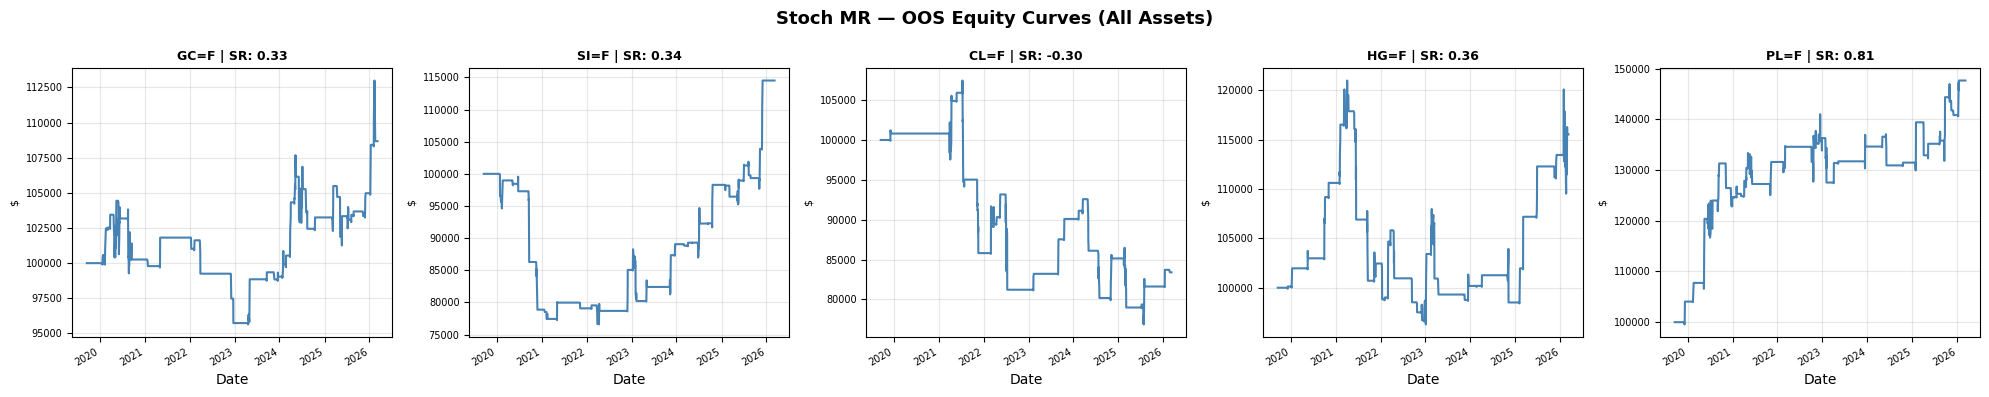

In [12]:
# ═══════════════════════════════════════════════════════════════
# MULTI-ASSET OOS VALIDATION
# ═══════════════════════════════════════════════════════════════

bp = best_params.copy()
sig_bp = {k: bp[k] for k in ['fastk', 'slowk', 'slowd', 'oversold', 'overbought', 'trend_period']}

print(f"Multi-Asset OOS Validation — Stoch MR best params")
print(f"{'='*100}")
print(f"{'Ticker':<8} {'IS SR':>8} {'OOS SR':>8} {'IS Trades':>10} {'OOS Trades':>11} {'OOS Ret':>9} {'OOS DD':>8} {'OOS WR':>8} {'OOS PF':>8}")
print(f"{'-'*100}")

multi_results = []
multi_portfolios = {}

for ticker in TICKERS:
    if ticker not in all_data:
        print(f"{ticker:<8} — NO DATA"); continue

    t_df = all_data[ticker]
    t_close = t_df['Close'].astype(float); t_close.name = 'price'
    t_high = t_df['High'].astype(float)
    t_low = t_df['Low'].astype(float)
    t_split = int(len(t_close) * TRAIN_RATIO)

    def safe(fn, default=np.nan):
        try: return float(fn())
        except: return default

    results_row = {'ticker': ticker}

    for label, slc in [('is', slice(0, t_split)), ('oos', slice(t_split, None))]:
        try:
            c, h, l = t_close.iloc[slc], t_high.iloc[slc], t_low.iloc[slc]
            ent, ext = generate_stoch_mr_signals(c, h, l, **sig_bp)
            sl, tp = compute_atr_stops(c, h, l, sl_mult=bp['sl_atr_mult'], tp_mult=bp['tp_atr_mult'])
            kw = dict(init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, freq='D')
            if sl is not None: kw['sl_stop'] = sl
            if tp is not None: kw['tp_stop'] = tp
            pf = vbt.Portfolio.from_signals(close=c, entries=ent, exits=ext, **kw)
            results_row[f'{label}_sharpe'] = safe(lambda: pf.sharpe_ratio(freq='D'))
            results_row[f'{label}_trades'] = pf.trades.count()
            if label == 'oos':
                results_row['oos_return'] = safe(pf.total_return)
                results_row['oos_maxdd'] = safe(pf.max_drawdown)
                tr = np.asarray(pf.trades.returns.values if hasattr(pf.trades.returns, 'values') else pf.trades.returns).ravel()
                pos = tr[tr > 0]; neg = tr[tr < 0]
                results_row['oos_wr'] = float(len(pos)/len(tr)*100) if len(tr) > 0 else np.nan
                results_row['oos_pf'] = float(pos.sum()/abs(neg.sum())) if len(neg) > 0 and abs(neg.sum()) > 0 else np.nan
            multi_portfolios[(ticker, label)] = pf
        except:
            results_row[f'{label}_sharpe'] = np.nan
            results_row[f'{label}_trades'] = 0

    multi_results.append(results_row)
    r = results_row
    fmt = lambda v, f: f.format(v) if not np.isnan(v) else "N/A"
    print(f"{ticker:<8} {fmt(r.get('is_sharpe',np.nan),'{:.3f}'):>8} {fmt(r.get('oos_sharpe',np.nan),'{:.3f}'):>8} "
          f"{r.get('is_trades',0):>10} {r.get('oos_trades',0):>11} "
          f"{fmt(r.get('oos_return',np.nan),'{:.2%}'):>9} {fmt(r.get('oos_maxdd',np.nan),'{:.2%}'):>8} "
          f"{fmt(r.get('oos_wr',np.nan),'{:.1f}%'):>8} {fmt(r.get('oos_pf',np.nan),'{:.2f}'):>8}")

# Plot OOS equity curves
fig, axes = plt.subplots(1, len(TICKERS), figsize=(4*len(TICKERS), 4))
fig.suptitle('Stoch MR — OOS Equity Curves (All Assets)', fontsize=13, fontweight='bold')
if len(TICKERS) == 1: axes = [axes]

for i, ticker in enumerate(TICKERS):
    ax = axes[i]
    pf = multi_portfolios.get((ticker, 'oos'))
    r = [x for x in multi_results if x['ticker'] == ticker]
    if pf and r:
        pf.value().plot(ax=ax, color='steelblue', linewidth=1.5)
        sr = r[0].get('oos_sharpe', np.nan)
        sr_str = f"{sr:.2f}" if not np.isnan(sr) else "N/A"
        ax.set_title(f'{ticker} | SR: {sr_str}', fontsize=9, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'No trades', ha='center', va='center')
        ax.set_title(f'{ticker}', fontsize=9)
    ax.grid(alpha=0.3); ax.set_ylabel('$', fontsize=8); ax.tick_params(labelsize=7)

plt.tight_layout(); plt.show()

Using default FTMO rules



FTMO Monte Carlo — 10,000 paths x 30 days
Pass Rate                            0.0%
Fail (daily DD)                      0.0%
Fail (total DD)                      0.0%
Fail (time expired)                100.0%
Mean Final P&L            $           164
Median Final P&L          $           111


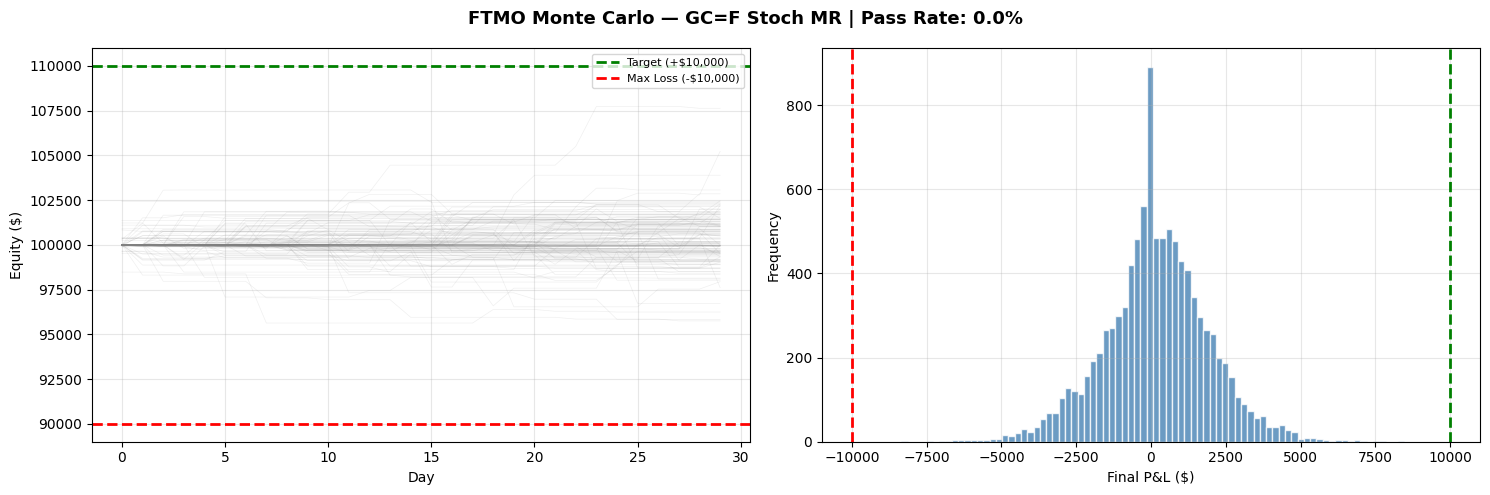

In [13]:
# ═══════════════════════════════════════════════════════════════
# FTMO MONTE CARLO — 10,000 paths x 30 days
# ═══════════════════════════════════════════════════════════════

import json

try:
    with open(os.path.join('config', 'ftmo_rules.json'), 'r') as f:
        ftmo_cfg = json.load(f)
    FTMO_ACCOUNT = ftmo_cfg['account_size']
    FTMO_PROFIT_TARGET = ftmo_cfg['profit_target_pct'] / 100
    FTMO_MAX_DAILY_DD = ftmo_cfg['max_daily_loss_pct'] / 100
    FTMO_MAX_TOTAL_DD = ftmo_cfg['max_total_loss_pct'] / 100
    FTMO_CHALLENGE_DAYS = ftmo_cfg['challenge_days']
    print("FTMO rules loaded from config")
except:
    FTMO_ACCOUNT = 100_000; FTMO_PROFIT_TARGET = 0.10
    FTMO_MAX_DAILY_DD = 0.05; FTMO_MAX_TOTAL_DD = 0.10; FTMO_CHALLENGE_DAYS = 30
    print("Using default FTMO rules")

N_PATHS = 10_000

# Use best OOS portfolio
pf_best_oos = oos_portfolios[best_idx]
daily_rets = pf_best_oos.returns().values.ravel()
daily_rets = daily_rets[~np.isnan(daily_rets)]

if len(daily_rets) > 10:
    account = FTMO_ACCOUNT
    target = account * FTMO_PROFIT_TARGET
    max_daily = account * FTMO_MAX_DAILY_DD
    max_total = account * FTMO_MAX_TOTAL_DD
    n_days = FTMO_CHALLENGE_DAYS

    pass_count = fail_daily = fail_total = fail_time = 0
    final_pnls = []; sample_paths = []

    np.random.seed(42)
    for s in range(N_PATHS):
        sampled = np.random.choice(daily_rets, size=n_days, replace=True)
        daily_pnl = account * sampled
        cum_pnl = np.cumsum(daily_pnl)
        equity = account + cum_pnl

        if np.min(daily_pnl) <= -max_daily: fail_daily += 1
        elif np.max(np.maximum.accumulate(equity) - equity) >= max_total: fail_total += 1
        elif np.any(cum_pnl >= target): pass_count += 1
        else: fail_time += 1

        final_pnls.append(cum_pnl[-1])
        if s < 150: sample_paths.append(equity)

    pass_rate = pass_count / N_PATHS
    final_pnls = np.array(final_pnls)

    print(f"\nFTMO Monte Carlo — {N_PATHS:,} paths x {n_days} days")
    print(f"{'='*55}")
    print(f"{'Pass Rate':<25} {pass_rate:>15.1%}")
    print(f"{'Fail (daily DD)':<25} {fail_daily/N_PATHS:>15.1%}")
    print(f"{'Fail (total DD)':<25} {fail_total/N_PATHS:>15.1%}")
    print(f"{'Fail (time expired)':<25} {fail_time/N_PATHS:>15.1%}")
    print(f"{'Mean Final P&L':<25} ${final_pnls.mean():>14,.0f}")
    print(f"{'Median Final P&L':<25} ${np.median(final_pnls):>14,.0f}")

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f'FTMO Monte Carlo — {TICKER} Stoch MR | Pass Rate: {pass_rate:.1%}', fontsize=13, fontweight='bold')

    for path in sample_paths:
        c = 'green' if path[-1] >= account + target else ('red' if path[-1] <= account - max_total else 'gray')
        axes[0].plot(path, color=c, alpha=0.12, linewidth=0.5)
    axes[0].axhline(account + target, color='green', linestyle='--', linewidth=2, label=f'Target (+${target:,.0f})')
    axes[0].axhline(account - max_total, color='red', linestyle='--', linewidth=2, label=f'Max Loss (-${max_total:,.0f})')
    axes[0].set_xlabel('Day'); axes[0].set_ylabel('Equity ($)'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    axes[1].hist(final_pnls, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
    axes[1].axvline(target, color='green', linestyle='--', linewidth=2)
    axes[1].axvline(-max_total, color='red', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Final P&L ($)'); axes[1].set_ylabel('Frequency'); axes[1].grid(alpha=0.3)

    plt.tight_layout(); plt.show()
else:
    print("Not enough data for Monte Carlo")

In [14]:
# ═══════════════════════════════════════════════════════════════
# UNIVERSAL EXPORT
# ═══════════════════════════════════════════════════════════════

import os, sys, json, datetime, shutil
from matplotlib.backends.backend_pdf import PdfPages

STRATEGY_NAME = "Stochastic_Mean_Reversion"
PARAM_COLS = ["fastk", "slowk", "slowd", "oversold", "overbought", "trend_period", "sl_atr_mult", "tp_atr_mult"]

EXPORT_DIR = "./strategy_exports"
try:
    from google.colab import drive
    if not os.path.exists('/content/drive'): drive.mount('/content/drive')
    EXPORT_DIR = "/content/drive/MyDrive/strategy_exports"
except: pass

RUN_ID = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
STRAT_DIR = os.path.join(EXPORT_DIR, STRATEGY_NAME, TICKER)
LATEST_DIR = os.path.join(STRAT_DIR, "latest")
ARCHIVE_DIR = os.path.join(STRAT_DIR, "archive")
os.makedirs(LATEST_DIR, exist_ok=True)
os.makedirs(ARCHIVE_DIR, exist_ok=True)

export_json = {
    "metadata": {
        "run_id": RUN_ID, "strategy_name": STRATEGY_NAME, "ticker": TICKER,
        "start_date": str(close_series.index[0].date()),
        "end_date": str(close_series.index[-1].date()),
        "total_bars": len(close_series), "train_ratio": TRAIN_RATIO,
        "init_cash": INIT_CASH, "fees_pct": FEES, "slippage_pct": SLIPPAGE,
        "grid_combos_tested": len(results_df),
    },
    "best_params": best_params,
    "oos_results": oos_results,
}

json_path = os.path.join(LATEST_DIR, "summary.json")
with open(json_path, 'w') as f:
    json.dump(export_json, f, indent=2, default=str)

results_df.to_csv(os.path.join(LATEST_DIR, "grid_results.csv"), index=False)
shutil.copy2(json_path, os.path.join(ARCHIVE_DIR, f"{RUN_ID}_summary.json"))

print(f"Export complete: {STRATEGY_NAME} / {TICKER}")
print(f"  Best params: {best_params}")
print(f"  Saved to: {LATEST_DIR}")

Export complete: Stochastic_Mean_Reversion / GC=F
  Best params: {'fastk': 9, 'slowk': 3, 'slowd': 5, 'oversold': 35, 'overbought': 70, 'trend_period': 50, 'sl_atr_mult': np.float64(2.5), 'tp_atr_mult': np.float64(3.0)}
  Saved to: ./strategy_exports\Stochastic_Mean_Reversion\GC=F\latest
